In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

font_dir = Path("/Users/sophiazhang/anaconda3/envs/shuoz/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf")
font_paths = [
    font_dir / "Myriad Pro Regular.ttf",
    font_dir / "Myriad Pro Bold.ttf",
    font_dir / "MYRIADPRO-SEMIBOLD.OTF"
]

for path in font_paths:
    font_manager.fontManager.addfont(str(path))

plt.rcParams["font.family"] = "Myriad Pro"

fs=16
fss=14

RESULTS_DIR = Path("./results")

In [17]:
# load data
metrics_fp = RESULTS_DIR / "digital_consumption_metrics_2000_2020.csv"
sda_fp = RESULTS_DIR / "sda_digital_va_2000_2020.csv"

df_metrics = pd.read_csv(metrics_fp)
df_sda = pd.read_csv(sda_fp)
df_metrics = df_metrics.sort_values("year")
df_metrics["year"] = df_metrics["year"].astype(int)
df_metrics = df_metrics.set_index("year")
full_years = np.arange(df_metrics.index.min(), df_metrics.index.max() + 1)  # 2000..2020
df_metrics = df_metrics.reindex(full_years)

# only interpolate numeric columns
num_cols = df_metrics.select_dtypes(include=[np.number]).columns
df_metrics[num_cols] = df_metrics[num_cols].interpolate(method="linear", limit_direction="both")
# bring back year column
df_metrics = df_metrics.reset_index().rename(columns={"index": "year"})
years = df_metrics["year"].astype(int)

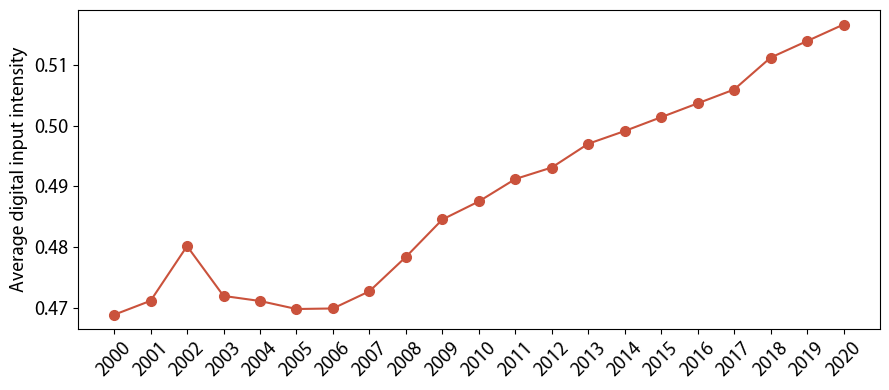

Saved: results/ts_avg_digital_input_intensity.png


In [18]:
def save_tight(fig, filename: str):
    fp = RESULTS_DIR / filename
    fig.tight_layout()
    fig.savefig(fp, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {fp}")
#  FIGURE 1: Avg digital input intensity
# =========================
fig, ax = plt.subplots(figsize=(9, 4), facecolor="none")
ax.plot(
    years,
    df_metrics["avg_digital_input_intensity"],
    marker="o",
    markersize=7,color="#CA523C",
)
ax.set_ylabel("Average digital input intensity", fontsize=fss)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(axis="y", labelsize=fss)
ax.set_facecolor("none")
save_tight(fig, "ts_avg_digital_input_intensity.png")

In [4]:
print(df_metrics)

    year  direct_digital_share_C  avg_digital_input_intensity  TotalVA_in_C  \
0   2000                0.051836                     0.468840  7.516077e+05   
1   2001                0.056995                     0.471143  8.027191e+05   
2   2002                0.071885                     0.480158  8.483934e+05   
3   2003                0.065088                     0.471944  8.853490e+05   
4   2004                0.069900                     0.471108  9.302758e+05   
5   2005                0.081985                     0.469787  1.191354e+06   
6   2006                0.083067                     0.469875  1.300233e+06   
7   2007                0.085855                     0.472713  1.550073e+06   
8   2008                0.093354                     0.478375  1.811455e+06   
9   2009                0.101094                     0.484549  1.960435e+06   
10  2010                0.104396                     0.487526  2.839789e+06   
11  2011                0.114082                    

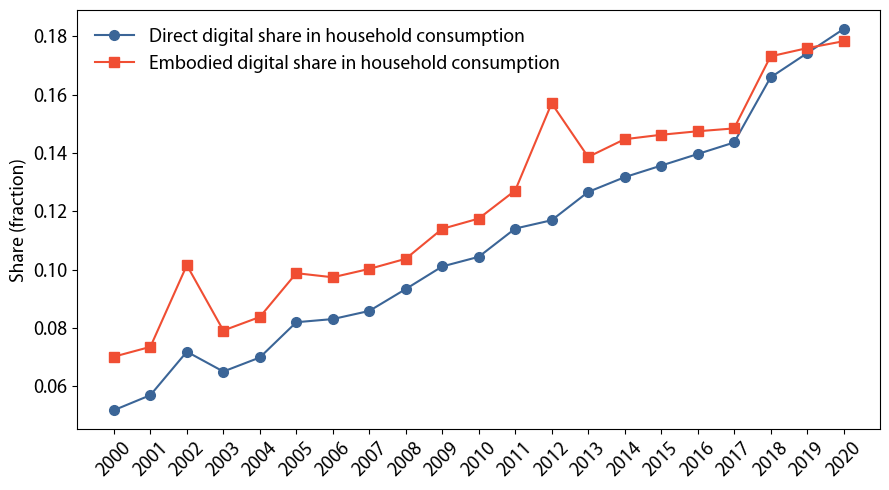

Saved: results/ts_direct_digital_share_C.png


In [28]:
# FIGURE 2: Direct digital share (C)
# =========================
df_metrics["DP_share_in_TotalVA"] = (
    df_metrics["DP_TotalEffect"] / df_metrics["TotalVA_in_C"]
)
fig, ax = plt.subplots(figsize=(9, 5), facecolor="none")
ax.plot(
    years,
    df_metrics["direct_digital_share_C"],
    marker="o",
    markersize=7,color="#3B6597",label="Direct digital share in household consumption"
)
ax.plot(
    years,
    df_metrics["DP_share_in_TotalVA"],
    marker="s",
    markersize=7,color="#F04E33",label="Embodied digital share in household consumption"
)
ax.set_ylabel("Share (fraction)", fontsize=fss)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(axis="y", labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.set_facecolor("none")
save_tight(fig, "ts_direct_digital_share_C.png")

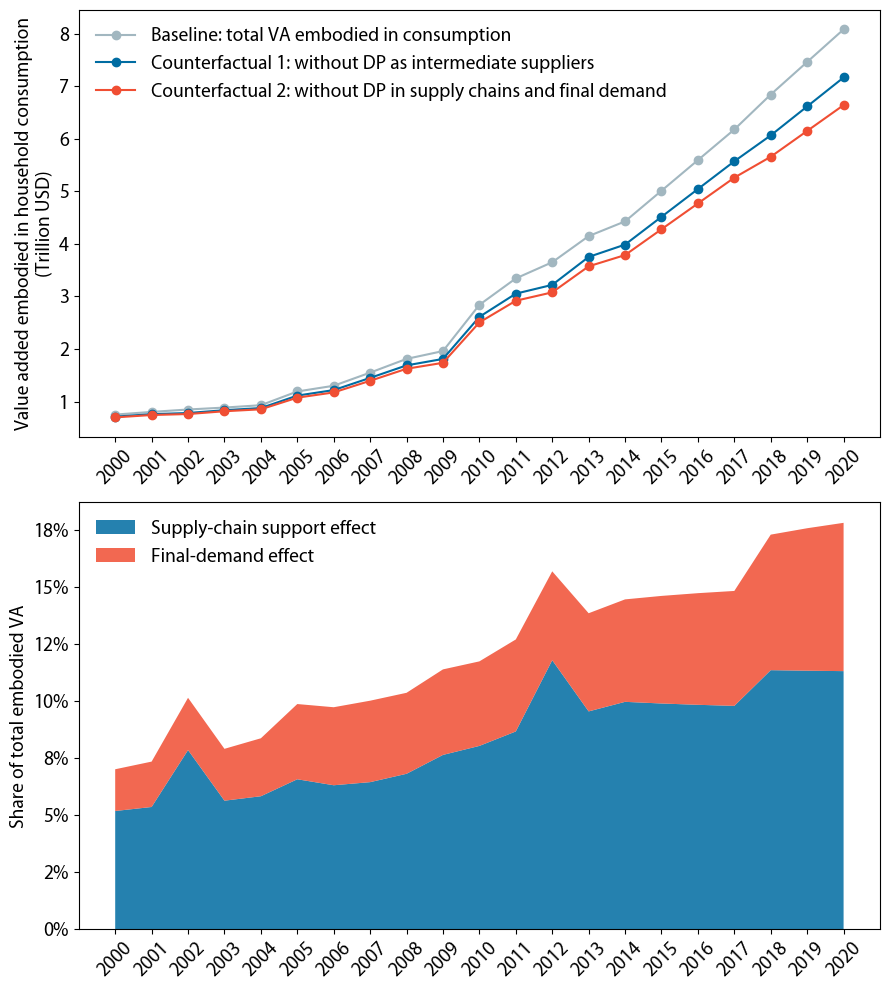

Saved: results/fig3_levels_and_shares_baseline_vs_counterfactuals.png


In [30]:
# FIGURE 3: Baseline TotalVA vs Counterfactuals
# =========================
# compute shares
df_metrics["DP_support_share"] = df_metrics["DP_Support"] / df_metrics["TotalVA_in_C"]
df_metrics["DP_finaldemand_share"] = df_metrics["DP_FinalDemand"] / df_metrics["TotalVA_in_C"]
df_metrics["DP_total_share"] = df_metrics["DP_support_share"] + df_metrics["DP_finaldemand_share"]

fig, axes = plt.subplots(2, 1, figsize=(9, 10), facecolor="none")
# -------------------------
# (a) Absolute levels
# -------------------------
ax = axes[0]
ax.plot(
    years,
    df_metrics["TotalVA_in_C"]/1e6, # convert to trillion USD
    marker="o",
    markersize=6,
    color="#A2B7C0",
    label="Baseline: total VA embodied in consumption",
)
ax.plot(
    years,
    df_metrics["TotalVA_in_C_minus_DP_supply"]/1e6, # convert to trillion USD
    marker="o",
    markersize=6,
    color="#006CA2",
    label="Counterfactual 1: without DP as intermediate suppliers",
)
ax.plot(
    years,
    df_metrics["TotalVA_in_C_minus_DP_supply_and_demand"]/1e6, # convert to trillion USD
    marker="o",
    markersize=6,
    color="#F04E33",
    label="Counterfactual 2: without DP in supply chains and final demand",
)

ax.set_ylabel("Value added embodied in household consumption\n(Trillion USD)", fontsize=fss)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(axis="y", labelsize=fss)
ax.legend(fontsize=fss, frameon=False, loc="upper left")
ax.set_facecolor("none")

# -------------------------
# (b) Shares (stacked)
# -------------------------
ax = axes[1]
ax.stackplot(
    years,
    df_metrics["DP_support_share"],
    df_metrics["DP_finaldemand_share"],
    labels=["Supply-chain support effect", "Final-demand effect"],
    colors=["#006CA2", "#F04E33"],
    alpha=0.85,
)

ax.set_ylabel("Share of total embodied VA", fontsize=fss)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(axis="y", labelsize=fss)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

ax.legend(fontsize=fss, frameon=False, loc="upper left")
ax.set_facecolor("none")

fig.tight_layout()
save_tight(fig, "fig3_levels_and_shares_baseline_vs_counterfactuals.png")
plt.show()
plt.close(fig)

In [21]:
print(df_metrics.head())

   year  direct_digital_share_C  avg_digital_input_intensity   TotalVA_in_C  \
0  2000                0.051836                     0.468840  751607.685541   
1  2001                0.056995                     0.471143  802719.055757   
2  2002                0.071885                     0.480158  848393.407946   
3  2003                0.065088                     0.471944  885348.950903   
4  2004                0.069900                     0.471108  930275.825587   

   TotalVA_in_C_minus_DP_supply  TotalVA_in_C_minus_DP_supply_and_demand  \
0                 712615.652873                            698857.400149   
1                 759663.508936                            743685.686875   
2                 781709.446894                            762259.842058   
3                 835411.829535                            815277.130487   
4                 875994.085745                            852341.048774   

     DP_Support  DP_FinalDemand  DP_TotalEffect  dp_identity_gap  \


In [15]:
print(df_metrics['year'], df_metrics["TotalVA_in_C"], df_metrics["TotalVA_in_C_minus_DP_supply"], df_metrics["TotalVA_in_C_minus_DP_supply_and_demand"])

0     2000
1     2001
2     2002
3     2003
4     2004
5     2005
6     2006
7     2007
8     2008
9     2009
10    2010
11    2011
12    2012
13    2013
14    2014
15    2015
16    2016
17    2017
18    2018
19    2019
20    2020
Name: year, dtype: int64 0     7.516077e+05
1     8.027191e+05
2     8.483934e+05
3     8.853490e+05
4     9.302758e+05
5     1.191354e+06
6     1.300233e+06
7     1.550073e+06
8     1.811455e+06
9     1.960435e+06
10    2.839789e+06
11    3.342718e+06
12    3.650583e+06
13    4.147690e+06
14    4.427818e+06
15    5.010718e+06
16    5.593619e+06
17    6.176519e+06
18    6.841888e+06
19    7.461318e+06
20    8.080749e+06
Name: TotalVA_in_C, dtype: float64 0     7.126157e+05
1     7.596635e+05
2     7.817094e+05
3     8.354118e+05
4     8.759941e+05
5     1.112966e+06
6     1.218097e+06
7     1.450040e+06
8     1.687917e+06
9     1.810503e+06
10    2.611391e+06
11    3.052672e+06
12    3.219754e+06
13    3.751314e+06
14    3.986095e+06
15    4.514493e+06
16    